 Taxi Fare Prediction — End-to-End Pipeline
### InDrive Dataset | Feature Engineering · Outlier Handling · Neural Network Regression

---
| Stage | Description |
|-------|-------------|
| 1 | Setup & Data Loading |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Data Cleaning — Nulls & Types |
| 4 | Outlier Detection & Treatment |
| 5 | Feature Engineering & Extraction |
| 6 | Feature Selection |
| 7 | Encoding & Scaling |
| 8 | Model Training (MLPRegressor) |
| 9 | Evaluation & Visualization |

## 1️⃣ Setup & Data Loading

In [359]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded")

Libraries loaded


In [360]:
df = pd.read_csv("dirty_taxi_fare_data.csv")
print(f" Shape: {df.shape}")
df.head()

 Shape: (21019, 27)


,distance_miles,app_version,fare_amount,payment_method,vehicle_type,row_uuid,surge_multiplier,fare_amount_plus_tip_leak,driver_id,driver_rating,car_year,duration_min,distance_km,server_log_id,dropoff_lon,pickup_lon,passenger_count,dropoff_city,pickup_datetime,pickup_city,weather,dropoff_lat,driver_age,pickup_lat,constant_col,trip_id,duration_sec
0,1.08,3.3.0,14.52,NaN,Economy,uuid-7722-8977,1.00,14.52,Driver_104,3.16,2008,7.180973176604898,1.7335425326790324,454330,31.23,31.22,3.0,Giza,2023-09-28 11:37:48,Mansoura,clear,30.06,25,30.07,v1,8722,430.86
1,1.22,3.2.1,13.81,Card,comfort,uuid-19624-7894,1.50,13.81,Driver_61,3.74,2010,5.163797028895367,1.9702782649209447,505125,31.24,31.23,1.0,Mansoura,2024-07-02 20:15:37,Alexandria,fog,30.03,35,30.02,v1,20624,309.83
2,1.28,NaN,14.16,card,Sedan,uuid-13780-9866,1.25,14.16,driver_343,4.21,2015,8.923401905401493,2.057512769560646,978323,31.14,31.11,2.0,Cairo,2023-12-23 04:07:50,Giza,Clear,29.80,64,29.79,v1,14780,535.40
3,13.74,3.3.0,79.58,cash,Comfort,uuid-2940-2635,1.00,79.58,Driver_292,4.76,2011,77.34284455834953,22.12044000553209,693336,31.33,31.24,1.0,NaN,2024-03-18 16:20:28,Cairo,Clear,30.03,51,30.31,v1,3940,4640.57
4,3.68,3.4.5,23.63,cash,SUV,uuid-20200-2920,1.00,23.63,Driver_179,4.94,2020,21.07719702272031,5.928120783871426,332878,31.40,31.50,1.0,Giza,2023-05-19 23:24:29,Cairo,fog,30.10,39,30.06,v1,17737,1264.63


## 2️⃣ Exploratory Data Analysis (EDA)

In [361]:
# --- Basic info ---
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 21019 entries, 0 to 21018
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   distance_miles             21019 non-null  float64
 1   app_version                16850 non-null  str    
 2   fare_amount                20600 non-null  str    
 3   payment_method             15254 non-null  str    
 4   vehicle_type               17175 non-null  str    
 5   row_uuid                   21019 non-null  str    
 6   surge_multiplier           21019 non-null  float64
 7   fare_amount_plus_tip_leak  20600 non-null  str    
 8   driver_id                  21019 non-null  str    
 9   driver_rating              19976 non-null  float64
 10  car_year                   21019 non-null  int64  
 11  duration_min               20519 non-null  str    
 12  distance_km                20513 non-null  str    
 13  server_log_id              21019 non-null  i

In [362]:
# --- Missing values summary ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("=" * 45)
print("MISSING VALUES")
print("=" * 45)
print(missing_df.to_string())

MISSING VALUES
                           Missing Count  Missing %
weather                             7584      36.08
payment_method                      5765      27.43
app_version                         4169      19.83
vehicle_type                        3844      18.29
dropoff_city                        3840      18.27
pickup_city                         3821      18.18
driver_rating                       1043       4.96
passenger_count                      929       4.42
distance_km                          506       2.41
duration_min                         500       2.38
fare_amount                          419       1.99
fare_amount_plus_tip_leak            419       1.99
pickup_lat                           209       0.99
dropoff_lon                          207       0.98
pickup_datetime                      101       0.48


In [363]:
# --- Numeric statistics ---
df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_miles,21019.00,3.91,3.72,0.19,1.26,2.73,5.34,35.27
surge_multiplier,21019.00,1.09,0.22,1.00,1.00,1.00,1.00,2.00
driver_rating,19976.00,4.03,0.58,3.00,3.56,4.03,4.54,5.00
car_year,21019.00,2014.15,5.51,2005.00,2009.00,2014.00,2019.00,2023.00
server_log_id,21019.00,548331.73,259690.18,100026.00,323555.50,549123.00,772992.50,999994.00
dropoff_lon,20812.00,31.25,0.25,30.29,31.08,31.25,31.42,32.26
pickup_lon,21019.00,31.25,0.25,30.35,31.08,31.25,31.42,32.16
dropoff_lat,21019.00,30.05,0.26,29.10,29.87,30.05,30.22,31.10
driver_age,21019.00,41.15,13.53,19.00,29.00,41.00,53.00,64.00
pickup_lat,20810.00,30.05,0.25,29.10,29.88,30.05,30.22,31.05


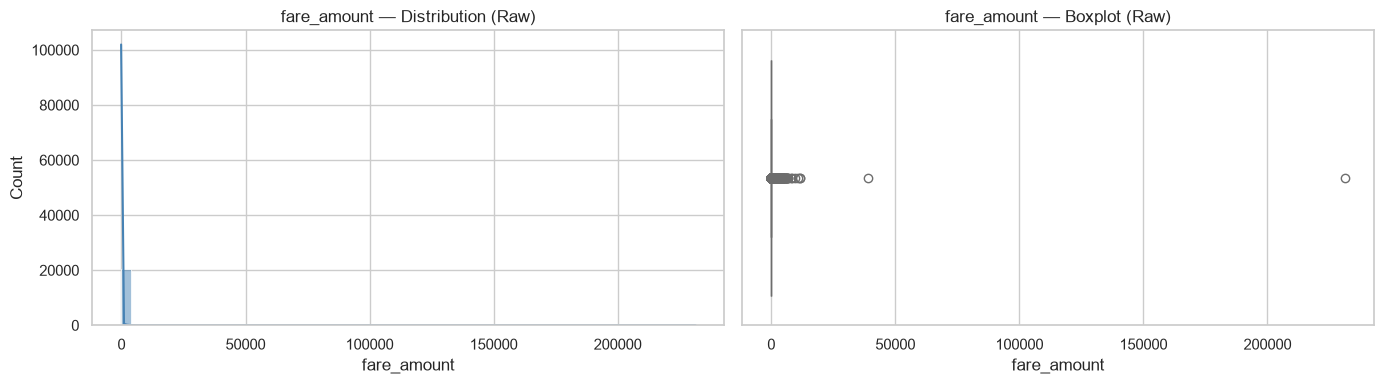

In [364]:
# --- Target distribution before cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['fare_amount'] = pd.to_numeric(df['fare_amount'], errors='coerce')

axes[0].set_title("fare_amount — Distribution (Raw)")
sns.histplot(df['fare_amount'].dropna(), bins=60, kde=True, ax=axes[0], color='steelblue')

axes[1].set_title("fare_amount — Boxplot (Raw)")
sns.boxplot(x=df['fare_amount'].dropna(), ax=axes[1], color='salmon')

plt.tight_layout()
plt.show()

## 3️⃣ Data Cleaning — Nulls, Types & Duplicates

In [365]:
# --- Drop leakage & irrelevant columns ---
DROP_COLS = [
    'app_version',       # irrelevant
    'row_uuid',          # irrelevant ID
    'server_log_id',     # irrelevant ID
    'constant_col',      # zero-variance
    'fare_amount_plus_tip_leak',  #  DATA LEAKAGE
    'distance_miles',    # redundant with distance_km (correlation=1)
    'duration_sec',      # redundant with duration_min (correlation=1)
    'driver_id',         # high-cardinality, needs entity resolution
]

df.drop(columns=DROP_COLS, inplace=True, errors='ignore')
print(f" Dropped {len(DROP_COLS)} columns | Remaining: {df.shape[1]}")

 Dropped 8 columns | Remaining: 19


In [366]:
# --- Remove exact duplicate rows ---
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f" Removed {before - len(df)} duplicate rows | Remaining: {len(df)}")

 Removed 261 duplicate rows | Remaining: 20758


In [367]:
# --- Convert mixed-type numeric columns to float ---
NUMERIC_COLS = ['fare_amount', 'distance_km', 'duration_min',
                'passenger_count', 'fare_amount']

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(" Numeric columns converted")
df[NUMERIC_COLS].dtypes

 Numeric columns converted


fare_amount        float64
distance_km        float64
duration_min       float64
passenger_count    float64
fare_amount        float64
dtype: object

In [368]:
# --- Parse pickup_datetime (mixed formats) ---
df['pickup_datetime'] = pd.to_datetime(
    df['pickup_datetime'],
    format='mixed',
    errors='coerce'
)

nulls_dt = df['pickup_datetime'].isna().sum()
print(f"  Unparseable datetime rows: {nulls_dt}  → will be dropped")
df = df.dropna(subset=['pickup_datetime'])
print(f" Datetime parsed | Rows remaining: {len(df)}")

  Unparseable datetime rows: 101  → will be dropped
 Datetime parsed | Rows remaining: 20657


In [369]:
# --- Clean categorical columns ---
cat_strip_lower = ['payment_method', 'vehicle_type',
                   'pickup_city', 'dropoff_city', 'weather']

for col in cat_strip_lower:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace({'nan': np.nan, 'none': np.nan, 'n/a': np.nan})

# Unify aliases
df['payment_method'] = df['payment_method'].replace({'credit_card': 'card'})

print(" Categorical columns normalised")

 Categorical columns normalised


In [370]:
# --- Fill remaining categorical nulls ---
df['payment_method'] = df['payment_method'].replace({'unknown': np.nan})
df['vehicle_type']   = df['vehicle_type'].replace({'unknown': np.nan})

for col in ['payment_method', 'vehicle_type', 'weather',
            'pickup_city', 'dropoff_city']:
    mode_val = df[col].mode(dropna=True)
    fill_val = mode_val[0] if not mode_val.empty else 'unknown'
    df[col].fillna(fill_val, inplace=True)

print(" Categorical nulls filled with mode")

 Categorical nulls filled with mode


In [371]:
# --- Fill numeric nulls ---
df['driver_rating'].fillna(df['driver_rating'].median(), inplace=True)
df['distance_km'].fillna(df['distance_km'].median(), inplace=True)
df['duration_min'].fillna(df['duration_min'].median(), inplace=True)
df['dropoff_lon'].fillna(df['dropoff_lon'].median(), inplace=True)
df['passenger_count'] = pd.to_numeric(df['passenger_count'], errors='coerce')
df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)

# Drop rows where target is still null
df = df.dropna(subset=['fare_amount'])

print(f" Numeric nulls filled | Rows remaining: {len(df)}")
print("\nMissing after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

 Numeric nulls filled | Rows remaining: 20192

Missing after cleaning:
payment_method     7159
vehicle_type       3704
driver_rating       993
duration_min        547
distance_km         564
dropoff_lon         201
passenger_count     954
dropoff_city       3704
pickup_city        3689
weather            7375
pickup_lat          197
dtype: int64


## 4️⃣ Outlier Detection & Treatment (IQR Method)

In [372]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

def plot_boxplot(series, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.boxplot(x=series, ax=axes[0], color='salmon')
    axes[0].set_title(f"{title} — Before")
    lower, upper = iqr_bounds(series)
    cleaned = series.clip(lower, upper)
    sns.boxplot(x=cleaned, ax=axes[1], color='mediumseagreen')
    axes[1].set_title(f"{title} — After Clipping")
    plt.tight_layout()
    plt.show()
    return lower, upper

print("Plotting outlier analysis...")

Plotting outlier analysis...


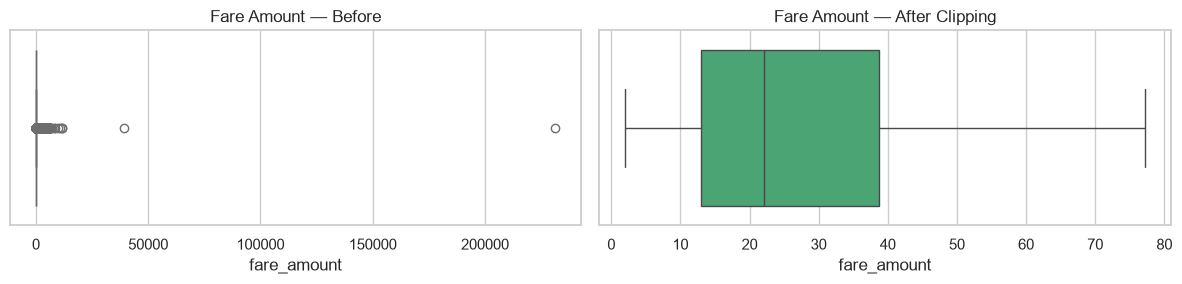

fare_amount: removed 1222 rows | bounds [-25.5, 77.2]


In [373]:
# --- fare_amount outliers ---
# Remove negative fares first
df = df[df['fare_amount'] >= 0]

lower, upper = plot_boxplot(df['fare_amount'], 'Fare Amount')
before = len(df)
df = df[(df['fare_amount'] >= lower) & (df['fare_amount'] <= upper)]
print(f"fare_amount: removed {before - len(df)} rows | bounds [{lower:.1f}, {upper:.1f}]")

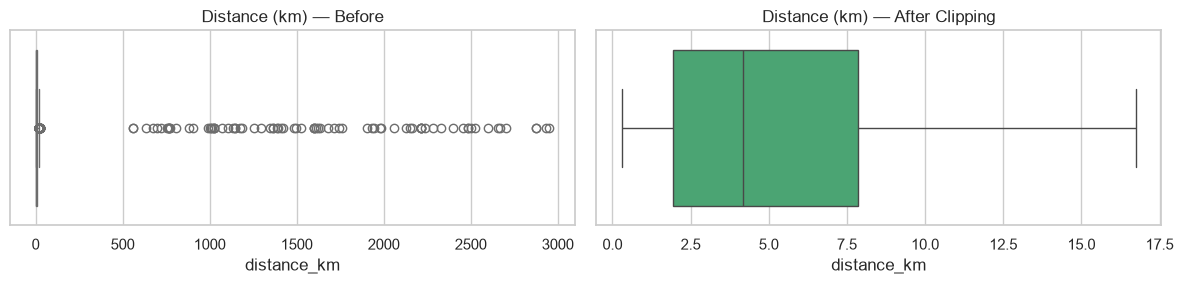

distance_km: removed 590 rows | bounds [-6.9, 16.7]


In [374]:
# --- distance_km outliers ---
# Remove impossible values (0 km with fare, or >200 km)
df = df[df['distance_km'] > 0]

lower, upper = plot_boxplot(df['distance_km'], 'Distance (km)')
before = len(df)
df = df[(df['distance_km'] >= lower) & (df['distance_km'] <= upper)]
print(f"distance_km: removed {before - len(df)} rows | bounds [{lower:.1f}, {upper:.1f}]")

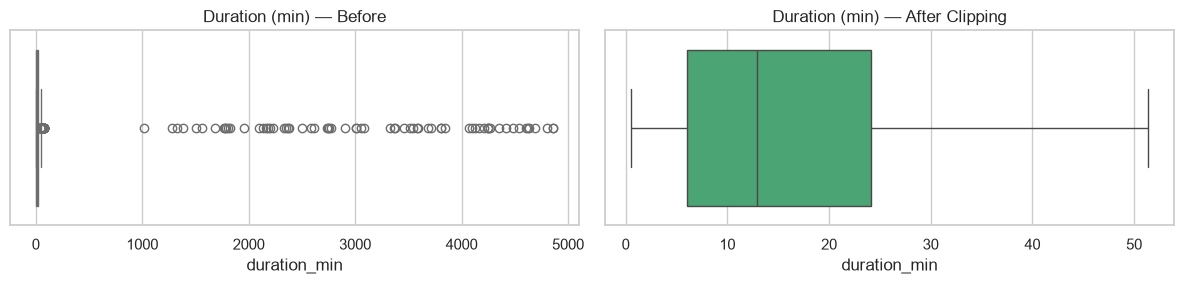

duration_min: removed 975 rows


In [375]:
# --- duration_min outliers ---
lower, upper = plot_boxplot(df['duration_min'], 'Duration (min)')
before = len(df)
df = df[(df['duration_min'] >= lower) & (df['duration_min'] <= upper)]
print(f"duration_min: removed {before - len(df)} rows")

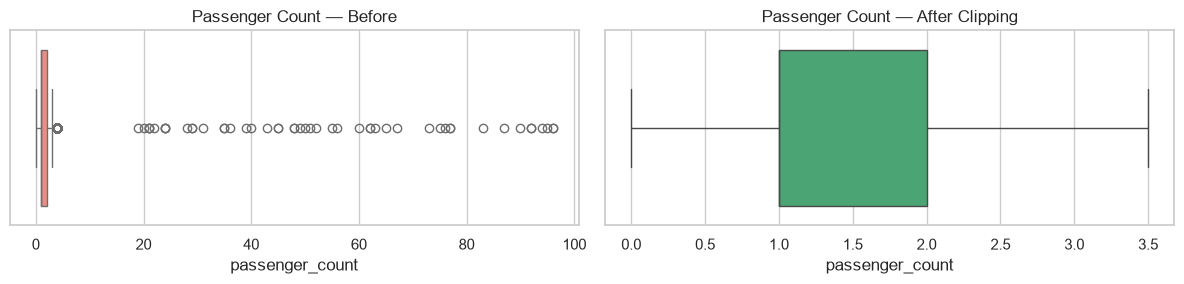

passenger_count: removed 2099 rows

 Final shape after outlier removal: (14587, 19)


In [376]:
# --- passenger_count outliers ---
lower, upper = plot_boxplot(df['passenger_count'], 'Passenger Count')
before = len(df)
df = df[(df['passenger_count'] >= lower) & (df['passenger_count'] <= upper)]
df = df[df['passenger_count'] >= 1]  # no zero passengers
print(f"passenger_count: removed {before - len(df)} rows")
print(f"\n Final shape after outlier removal: {df.shape}")

## 5️⃣ Feature Engineering & Extraction

In [377]:
# --- DateTime features ---
df['hour']     = df['pickup_datetime'].dt.hour
df['weekday']  = df['pickup_datetime'].dt.dayofweek
df['month']    = df['pickup_datetime'].dt.month
df['weekend']  = (df['weekday'] >= 5).astype(int)
df['rush_hour']= df['hour'].apply(lambda x: 1 if x in [7,8,9,16,17,18,19] else 0)
df['time_category'] = df['hour'].apply(
    lambda x: 'morning'   if  6 <= x < 12
    else       'afternoon' if 12 <= x < 18
    else       'night'
)

df.drop(columns=['pickup_datetime'], inplace=True)
print(" DateTime features extracted: hour, weekday, month, weekend, rush_hour, time_category")

 DateTime features extracted: hour, weekday, month, weekend, rush_hour, time_category


In [378]:
# --- Distance category (binning) ---
df['distance_category'] = pd.cut(
    df['distance_km'],
    bins=[0, 5, 15, np.inf],
    labels=['short', 'medium', 'long']
)
print(" distance_category created (short / medium / long)")

 distance_category created (short / medium / long)


In [379]:
# --- Geographic distance (Haversine) ---
# straight-line distance from coordinates as extra feature
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['coord_distance_km'] = haversine(
    df['pickup_lat'], df['pickup_lon'],
    df['dropoff_lat'], df['dropoff_lon']
)
print(" coord_distance_km calculated (Haversine)")

 coord_distance_km calculated (Haversine)


In [380]:
# --- Speed feature ---
df['avg_speed_kmh'] = (df['distance_km'] / (df['duration_min'] / 60)).clip(upper=150)
df['avg_speed_kmh'].fillna(df['avg_speed_kmh'].median(), inplace=True)
print("avg_speed_kmh derived from distance / duration")

avg_speed_kmh derived from distance / duration


In [381]:
# --- Car age ---
df['car_age'] = 2025 - df['car_year']
df.drop(columns=['car_year'], inplace=True)
print(" car_age calculated (2025 - car_year)")

print(f"\n Shape after feature engineering: {df.shape}")
df[['hour','weekend','rush_hour','coord_distance_km','avg_speed_kmh','car_age']].describe()

 car_age calculated (2025 - car_year)

 Shape after feature engineering: (14587, 27)


,hour,weekend,rush_hour,coord_distance_km,avg_speed_kmh,car_age
count,14587.00,14587.00,14587.00,14311.00,14587.00,14587.00
mean,11.32,0.28,0.29,4.21,25.02,10.91
std,7.04,0.45,0.45,4.24,22.49,5.51
min,0.00,0.00,0.00,0.01,1.91,2.00
25%,5.00,0.00,0.00,1.20,14.76,6.00
50%,11.00,0.00,0.00,2.82,18.75,11.00
75%,17.00,1.00,1.00,5.75,25.19,16.00
max,23.00,1.00,1.00,34.64,150.00,20.00


## 6️⃣ Encoding Categorical Features

In [382]:
# --- One-Hot Encoding ---
OHE_COLS = [
    'payment_method',
    'vehicle_type',
    'pickup_city',
    'dropoff_city',
    'weather',
    'time_category',
    'distance_category',
]

df = pd.get_dummies(df, columns=OHE_COLS, drop_first=False)

# Convert booleans to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f" One-Hot Encoding applied | Shape: {df.shape}")

 One-Hot Encoding applied | Shape: (14587, 45)


## 7️⃣ Feature Selection

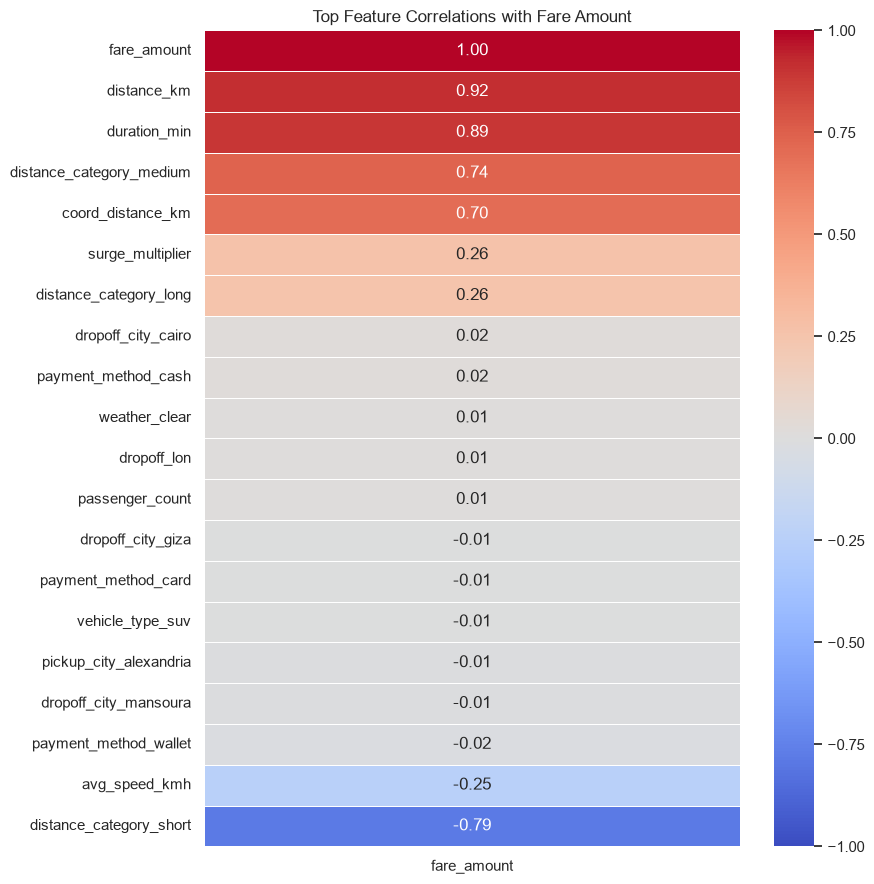

In [383]:
# --- Correlation with target ---
corr = df.corr(numeric_only=True)['fare_amount'].sort_values(ascending=False)

top_pos = corr.head(12)
top_neg = corr.tail(8)
top_corr = pd.concat([top_pos, top_neg]).drop_duplicates()

plt.figure(figsize=(9, 9))
sns.heatmap(
    top_corr.to_frame(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Top Feature Correlations with Fare Amount")
plt.tight_layout()
plt.show()

In [384]:
# --- Drop low-correlation & coordinate raw columns after haversine ---
# Raw coords add noise after we derived coord_distance_km
DROP_LOW = ['pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon']
df.drop(columns=DROP_LOW, inplace=True, errors='ignore')

print(f" Dropped raw coordinate columns")
print(f" Final feature set: {df.shape[1] - 1} features + 1 target")

 Dropped raw coordinate columns
 Final feature set: 40 features + 1 target


In [385]:
# ── Fill remaining nulls ────────────────────────────────────────

# driver_rating → median (robust to skew)
df['driver_rating'] = df['driver_rating'].fillna(df['driver_rating'].median())

# coord_distance_km → median (some coords were null so haversine returned NaN)
df['coord_distance_km'] = df['coord_distance_km'].fillna(df['coord_distance_km'].median())

# ── Confirm ─────────────────────────────────────────────────────
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

if remaining.empty:
    print(" No nulls remaining")
else:
    print(" Still has nulls:")
    print(remaining)

 No nulls remaining


In [386]:
df.isnull().sum()

fare_amount                 0
surge_multiplier            0
driver_rating               0
duration_min                0
distance_km                 0
passenger_count             0
driver_age                  0
trip_id                     0
hour                        0
weekday                     0
month                       0
weekend                     0
rush_hour                   0
coord_distance_km           0
avg_speed_kmh               0
car_age                     0
payment_method_card         0
payment_method_cash         0
payment_method_wallet       0
vehicle_type_comfort        0
vehicle_type_economy        0
vehicle_type_lux            0
vehicle_type_sedan          0
vehicle_type_suv            0
pickup_city_alexandria      0
pickup_city_cairo           0
pickup_city_giza            0
pickup_city_mansoura        0
dropoff_city_alexandria     0
dropoff_city_cairo          0
dropoff_city_giza           0
dropoff_city_mansoura       0
weather_clear               0
weather_fo

In [387]:
df.info()

<class 'pandas.DataFrame'>
Index: 14587 entries, 0 to 20757
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fare_amount               14587 non-null  float64
 1   surge_multiplier          14587 non-null  float64
 2   driver_rating             14587 non-null  float64
 3   duration_min              14587 non-null  float64
 4   distance_km               14587 non-null  float64
 5   passenger_count           14587 non-null  float64
 6   driver_age                14587 non-null  int64  
 7   trip_id                   14587 non-null  int64  
 8   hour                      14587 non-null  int32  
 9   weekday                   14587 non-null  int32  
 10  month                     14587 non-null  int32  
 11  weekend                   14587 non-null  int64  
 12  rush_hour                 14587 non-null  int64  
 13  coord_distance_km         14587 non-null  float64
 14  avg_speed_kmh         

## 8️⃣ Model Training — MLP Neural Network

In [388]:

X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

 Train: (11669, 40) | Test: (2918, 40)


In [389]:
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

model.fit(X_train_scaled, y_train)
print(f" Training complete | Iterations: {model.n_iter_}")

 Training complete | Iterations: 45


## 9️⃣ Evaluation & Visualization

In [390]:

y_pred = model.predict(X_test_scaled).clip(min=0)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL PERFORMANCE")
print("=" * 40)
print(f"  MAE      : {mae:.3f}")
print(f"  MSE      : {mse:.3f}")
print(f"  RMSE     : {rmse:.3f}")
print(f"  R² Score : {r2:.4f}")
print("=" * 40)

       MODEL PERFORMANCE
  MAE      : 1.823
  MSE      : 5.202
  RMSE     : 2.281
  R² Score : 0.9733


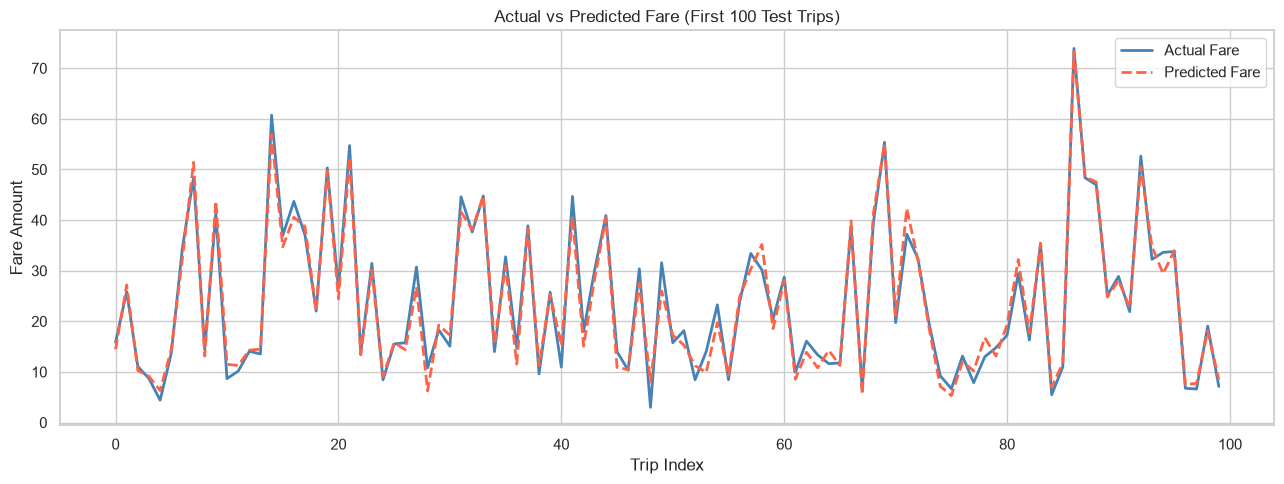

In [391]:
# --- Actual vs Predicted (first 100 test samples) ---
plt.figure(figsize=(13, 5))
plt.plot(y_test.values[:100], label='Actual Fare',    color='steelblue',  lw=2)
plt.plot(y_pred[:100],        label='Predicted Fare', color='tomato', lw=2, linestyle='--')
plt.xlabel("Trip Index")
plt.ylabel("Fare Amount")
plt.title("Actual vs Predicted Fare (First 100 Test Trips)")
plt.legend()
plt.tight_layout()
plt.show()

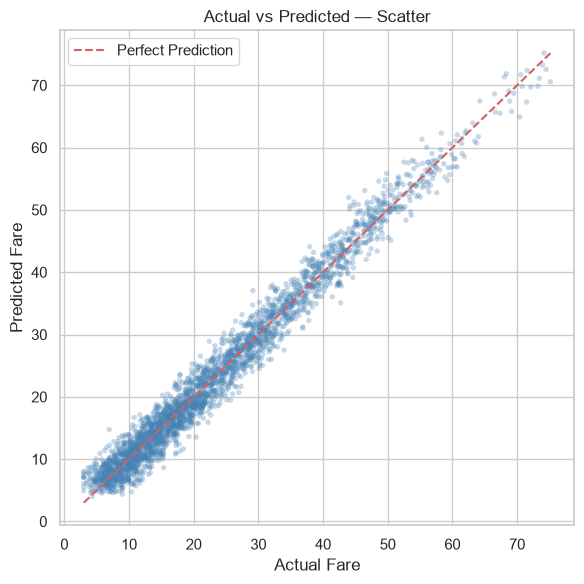

In [392]:
# --- Scatter: Actual vs Predicted ---
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none', s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted — Scatter")
plt.legend()
plt.tight_layout()
plt.show()

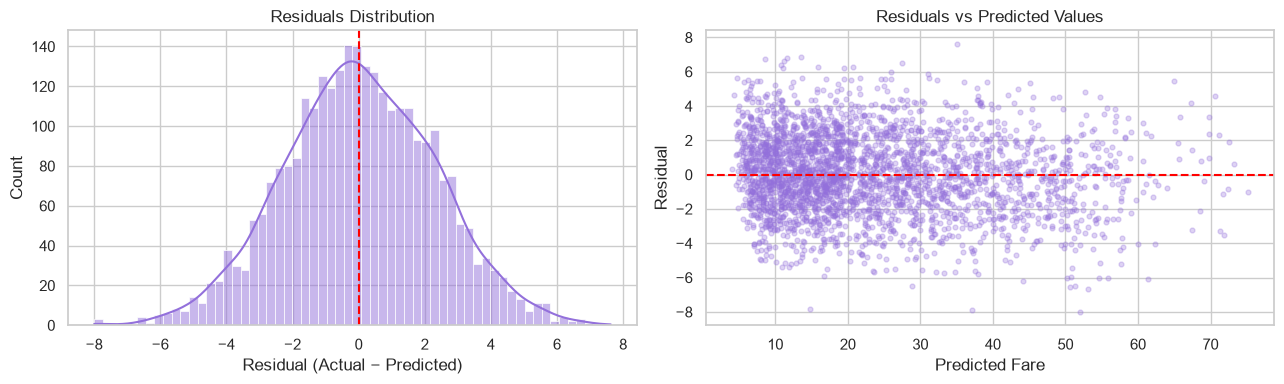

In [393]:
# --- Residuals distribution ---
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(residuals, bins=60, kde=True, ax=axes[0], color='mediumpurple')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title("Residuals Distribution")
axes[0].set_xlabel("Residual (Actual − Predicted)")

axes[1].scatter(y_pred, residuals, alpha=0.3, s=12, color='mediumpurple')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Residuals vs Predicted Values")
axes[1].set_xlabel("Predicted Fare")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [394]:
# --- Sample predictions table ---
result = pd.DataFrame({
    'Actual Fare':    y_test.values[:15],
    'Predicted Fare': y_pred[:15].round(2),
    'Error':         (y_test.values[:15] - y_pred[:15]).round(2)
})
result.index = range(1, 16)
print("Sample Predictions:")
result

Sample Predictions:


,Actual Fare,Predicted Fare,Error
1,15.84,14.46,1.38
2,25.85,27.19,-1.34
3,11.08,10.26,0.82
4,8.66,9.11,-0.45
5,4.41,6.31,-1.90
6,13.67,14.45,-0.78
7,34.54,32.46,2.08
8,48.45,51.42,-2.97
9,14.42,13.12,1.30
10,41.31,43.79,-2.48
